<a href="https://colab.research.google.com/github/Paltaxd2/Evaluacion1_Programacion_Ciencia_Datos/blob/Joaquin/Progra_EV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_store_sales.csv')

df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


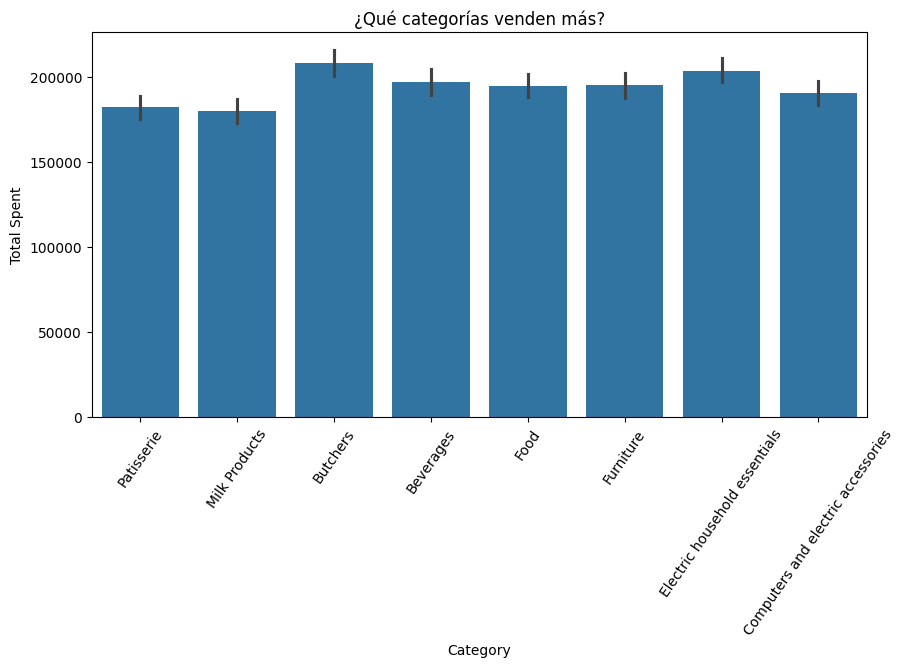

In [ ]:
# Categoría vs Total gastado

# gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='Category',
    y='Total Spent',
    estimator=sum
)

plt.title('¿Qué categorías venden más?', fontsize=12)
plt.xlabel('Categoría', fontsize=10)
plt.ylabel('Total Spent', fontsize=10)
plt.xticks(rotation=55)
plt.show()

Las categorías con barras más altas, como "Butchers", son las que generan mayores ingresos para la tienda. Si "Butchers" llegase a dominar ampliamente, el negocio podría depender mucho de ese tipo de producto. Se podría promocionar o hacer una revisión de inventario de las categorías con ventas bajas.


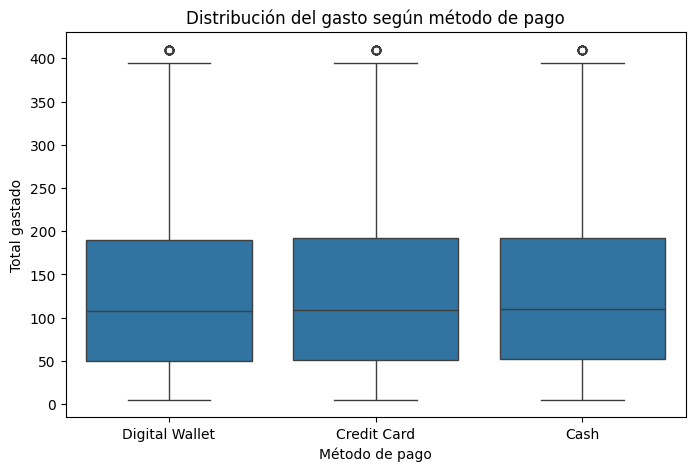

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Payment Method',
    y='Total Spent',
    data=df
)

plt.title('Distribución del gasto según método de pago')
plt.xlabel('Método de pago', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.show()

In [ ]:
df.groupby('Payment Method')['Total Spent'].mean()

,Total Spent
Payment Method,
Cash,131.052888
Credit Card,129.127069
Digital Wallet,128.718346


Si una caja tiene una mediana más alta, significa que ese método suele usarse en compras más grandes. Muchos outliers indican compras excepcionalmente altas. Una distribución muy dispersa muestra gran variabilidad en el gasto.

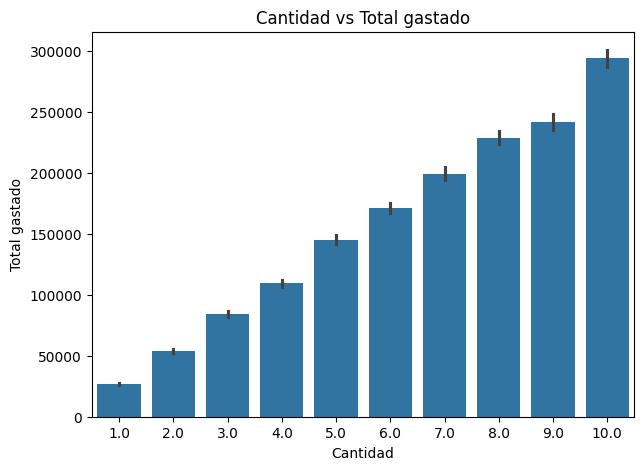

In [ ]:
# Categoría vs Total gastado

# gráfico de barras
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x='Quantity',
    y='Total Spent',
    estimator=sum
)

plt.title('Cantidad vs Total gastado', fontsize=12)
plt.xlabel('Cantidad', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.show()


Ya que las barras forman una diagonal ascendente, existe una relación positiva: a mayor cantidad comprada, mayor gasto.

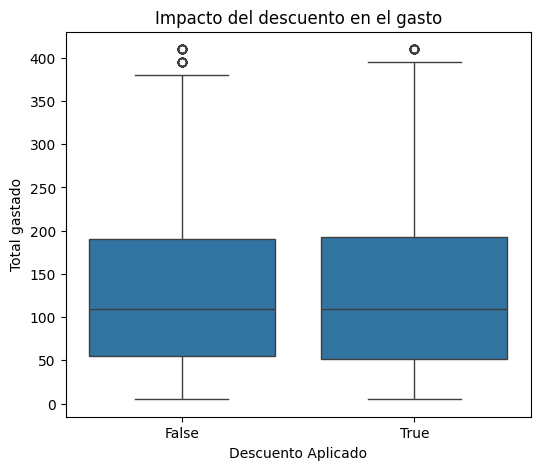

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x='Discount Applied',
    y='Total Spent',
    data=df
)

plt.title('Impacto del descuento en el gasto')
plt.xlabel('Descuento Aplicado', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.show()

In [ ]:
df.groupby('Discount Applied')['Total Spent'].mean()

,Total Spent
Discount Applied,
False,129.953330
True,130.491043


Ya que ambos grupos son similares, el descuento no estaría generando gran impacto.

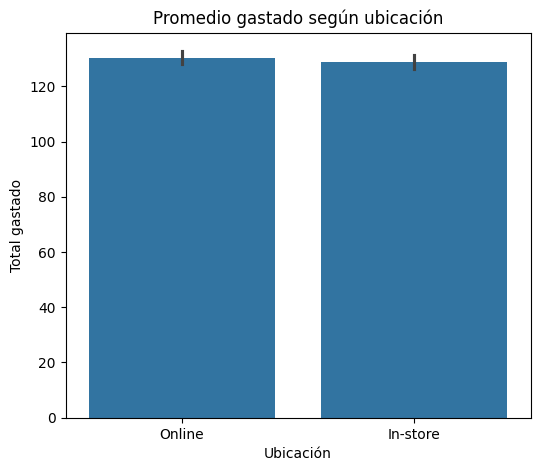

In [ ]:
plt.figure(figsize=(6,5))

sns.barplot(
    x='Location',
    y='Total Spent',
    data=df,
    estimator='mean'
)

plt.title('Promedio gastado según ubicación')
plt.xlabel('Ubicación', fontsize=10)
plt.ylabel('Total gastado', fontsize=10)
plt.show()

In [ ]:
df.groupby('Location')['Total Spent'].mean()

,Total Spent
Location,
In-store,128.861596
Online,130.422050


Las ventas online presentan un promedio del total gastado más alto que las realizadas en tienda física, aunque no por mucho.

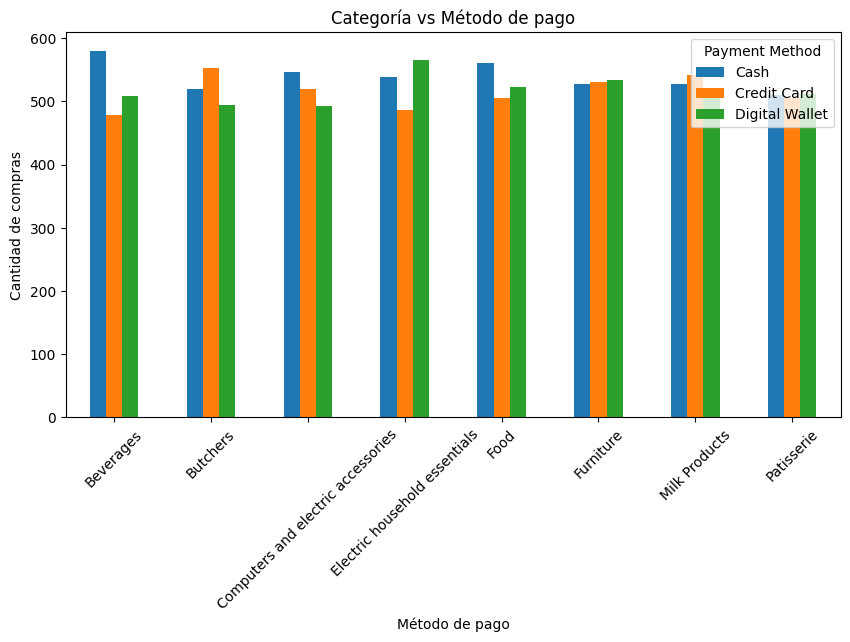

In [ ]:
categ_metodo = pd.crosstab(df['Category'], df['Payment Method'])

categ_metodo.plot(kind='bar', figsize=(10,5))

plt.title('Categoría vs Método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Cantidad de compras')
plt.xticks(rotation=45)
plt.show()

Los productos bebestibles y comida tienen un comportamiento similar, puede que esto se deba a que se suelen comprar en conjunto.

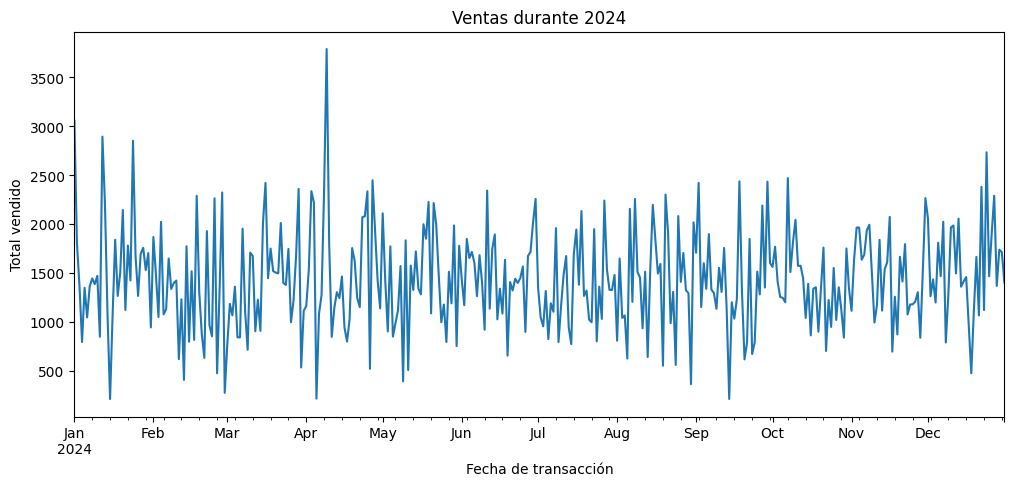

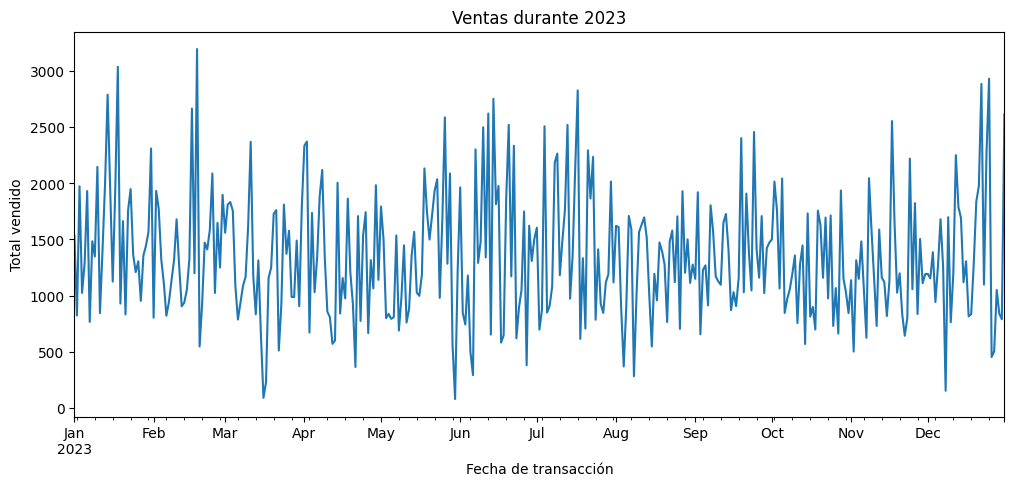

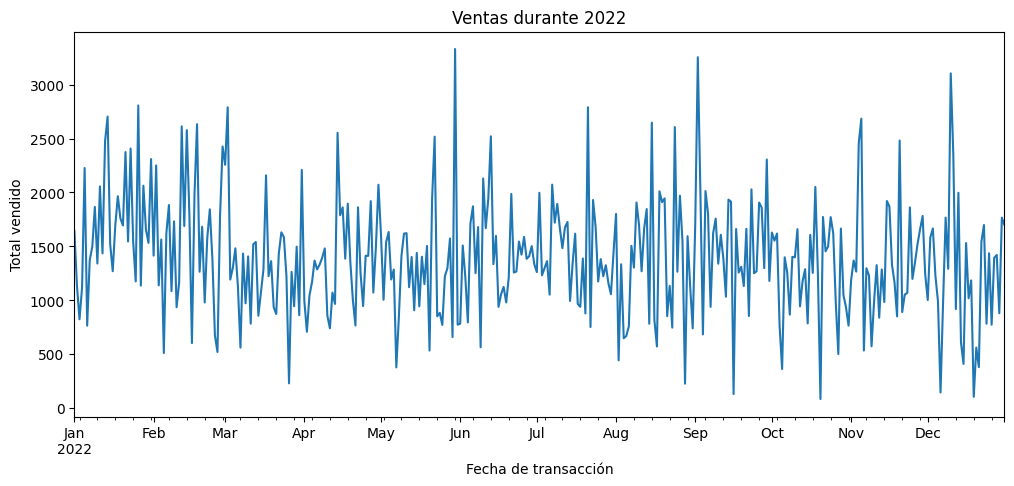

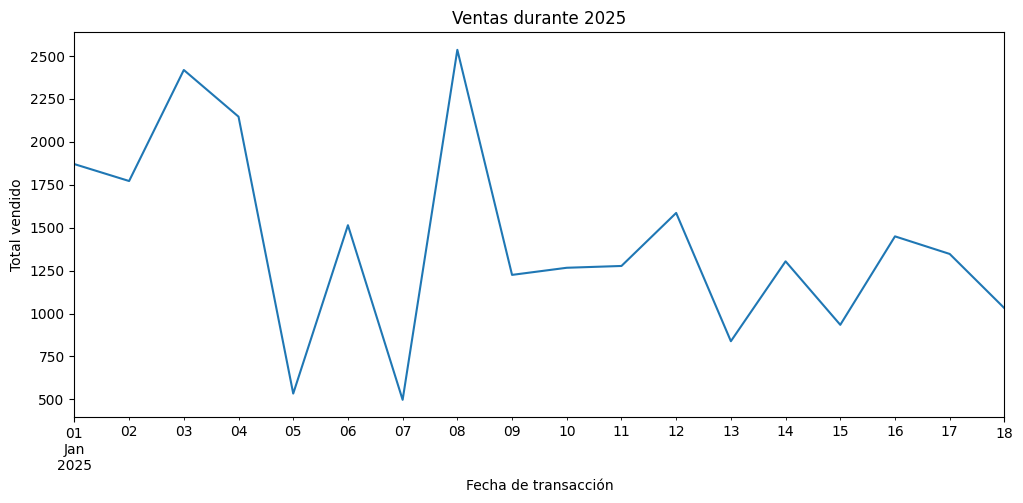

In [ ]:
df['Year'] = df['Transaction Date'].dt.year

años = df['Year'].unique()

for año in años:

    datos_año = df[df['Year'] == año]

    ventas_fecha = datos_año.groupby('Transaction Date')['Total Spent'].sum()

    plt.figure(figsize=(12,5))

    ventas_fecha.plot()

    plt.title(f'Ventas durante {año}')
    plt.xlabel('Fecha de transacción')
    plt.ylabel('Total vendido')

    plt.show()

Solo en diciembre de cada año parece haber comportamientos similares en las ventas, puede deberse a las festividades cercanas como navidad y año nuevo. Los otros meses muestran comportamientos diferentes, ni siquiera se llegan a repetir de un año al siguiente, por ejemplo en abril de 2024, se muestra un pico muy alto de ventas pero solo en ese año, en 2022 y 2023 ni siquiera resalta.